# Unidad 2: Aprendizaje Automático
## 🔧 Preprocesamiento de Datos con scikit-learn
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/23_Preprocessing.ipynb)

## 🎯 ¿Qué vamos a aprender?

El **preprocesamiento** (o *preprocessing*) es el conjunto de transformaciones que aplicamos a los datos **antes** de entrenar un modelo. Es un paso crítico: muchos algoritmos de ML son sensibles a la escala, la distribución y el tipo de las variables.

Al finalizar, vas a poder:
- ✅ Entender por qué es necesario transformar los datos antes de aplicar ML
- ✅ Aplicar **Binarización** con `Binarizer`
- ✅ Estandarizar datos con **StandardScaler** (media = 0, desviación = 1)
- ✅ Reescalar al rango [0, 1] con **MinMaxScaler**
- ✅ Normalizar vectores con normas **L1** y **L2**
- ✅ Codificar variables categóricas con **LabelEncoder**

---

## 🧠 Marco Teórico

### ¿Por qué es necesario el preprocesamiento?

Los datos del mundo real rara vez vienen listos para entrenar un modelo. Algunos problemas típicos:

| Problema | Ejemplo | Solución |
|----------|---------|----------|
| Variables en escalas muy distintas | Salario (miles) vs Edad (decenas) | Escalado / Estandarización |
| Variables categóricas | `'rojo'`, `'verde'` | Codificación (Label / One-Hot) |
| Distribuciones asimétricas | Ingresos | Normalización |
| Valores binarios | Presencia/ausencia de un síntoma | Binarización |

> ⚠️ Algoritmos como **KNN** y **SVM** son especialmente sensibles a la escala de las variables, ya que computan distancias entre puntos. Una variable con rango grande dominaría sobre las demás.

---



### 📐 Estandarización vs. Normalización

Dos de las técnicas más usadas suelen confundirse:

#### Estandarización (StandardScaler)

Transforma los datos para que tengan **media = 0** y **desviación estándar = 1**:

$$z = \frac{x - \mu}{\sigma}$$

- ✅ Ideal cuando los datos siguen una distribución aproximadamente normal
- ✅ Recomendada para: **Regresión Lineal, SVM, PCA**
- ⚠️ No garantiza un rango fijo de valores

#### Normalización MinMax

Reescala los datos a un intervalo **[0, 1]** (o cualquier rango definido):

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- ✅ Ideal cuando los datos no siguen distribución normal
- ✅ Recomendada para: **KNN, Redes Neuronales, Clustering**
- ⚠️ Muy sensible a valores atípicos (*outliers*)

#### Normalización de vectores (L1 / L2)

Escala cada **fila** (muestra) para que su norma sea 1:

$$||x||_1 = \sum_i |x_i| = 1 \qquad \text{(norma L1)}$$

$$||x||_2 = \sqrt{\sum_i x_i^2} = 1 \qquad \text{(norma L2)}$$

- ✅ Útil cuando la magnitud absoluta no importa, sino la dirección del vector
- ✅ Muy usada en procesamiento de texto (TF-IDF)

> 📌 **Referencia:** [scikit-learn — Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)

---

## 📦 Paso 1: Importar las Librerías

In [10]:
import numpy as np
from sklearn import preprocessing

print('✅ Librerías importadas correctamente!')

✅ Librerías importadas correctamente!


## 📊 Paso 2: Definir los Datos de Entrada

Usamos una matriz numérica con valores en **escalas muy distintas** para ver el efecto de cada transformación:

In [2]:
input_data = np.array([[ 500.1, -2.9,  3.3],
                       [-100.2,  7.8, -6.1],
                       [ 300.9,  0.4,  2.1],
                       [ 700.3, -9.9, -4.5]])

print('📋 Datos originales (sin procesar):')
print(input_data)
print(f'\n📐 Forma: {input_data.shape}  →  4 muestras x 3 features')
print(f'\n📈 Mínimos por columna:  {input_data.min(axis=0)}')
print(f'📉 Máximos por columna:  {input_data.max(axis=0)}')
print(f'📊 Medias por columna:   {input_data.mean(axis=0).round(2)}')

📋 Datos originales (sin procesar):
[[ 5.001e+02 -2.900e+00  3.300e+00]
 [-1.002e+02  7.800e+00 -6.100e+00]
 [ 3.009e+02  4.000e-01  2.100e+00]
 [ 7.003e+02 -9.900e+00 -4.500e+00]]

📐 Forma: (4, 3)  →  4 muestras x 3 features

📈 Mínimos por columna:  [-100.2   -9.9   -6.1]
📉 Máximos por columna:  [700.3   7.8   3.3]
📊 Medias por columna:   [350.28  -1.15  -1.3 ]


## 🔲 Paso 3: Binarización

La **Binarización** convierte valores numéricos a binarios (0 o 1) según un umbral (*threshold*):
- Valores **estrictamente mayores** al umbral → `1`
- Valores **menores o iguales** al umbral → `0`

> 💡 **Caso de uso:** convertir intensidades de píxeles a blanco/negro, o presencia/ausencia de un síntoma médico.

In [3]:
# Binarización con threshold=2.1
# Valores > 2.1 → 1  |  Valores ≤ 2.1 → 0
data_binarized = preprocessing.Binarizer(threshold=2.1).transform(input_data)

print('🔲 Datos binarizados (threshold=2.1):')
print(data_binarized)
print('\n💡 Nota: el valor 2.1 en la tercera fila NO es > 2.1, por eso es 0.')

🔲 Datos binarizados (threshold=2.1):
[[1. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]

💡 Nota: el valor 2.1 en la tercera fila NO es > 2.1, por eso es 0.


## 📏 Paso 4: Estandarización — Remoción de la Media (StandardScaler)

**`preprocessing.scale()`** (o `StandardScaler`) transforma cada feature para que tenga:
- **Media = 0**
- **Desviación estándar = 1**

$$z = \frac{x - \mu}{\sigma}$$

Esto centra los datos y los hace comparables independientemente de su escala original.

In [4]:
# Estadísticas ANTES de estandarizar
print('📊 Antes de estandarizar:')
print(f'  Media por columna:   {input_data.mean(axis=0).round(4)}')
print(f'  Desv. std por col.:  {input_data.std(axis=0).round(4)}')

# Estandarización: resta la media y divide por la desviación estándar
data_scaled = preprocessing.scale(input_data)

print('\n📊 Después de estandarizar (StandardScaler):')
print(data_scaled.round(4))
print(f'\n  Media por columna:   {data_scaled.mean(axis=0).round(10)}  ≈ 0')
print(f'  Desv. std por col.:  {data_scaled.std(axis=0).round(4)}  ≈ 1')

📊 Antes de estandarizar:
  Media por columna:   [350.275  -1.15   -1.3  ]
  Desv. std por col.:  [295.9437   6.3665   4.062 ]

📊 Después de estandarizar (StandardScaler):
[[ 0.5063 -0.2749  1.1324]
 [-1.5222  1.4058 -1.1817]
 [-0.1668  0.2435  0.837 ]
 [ 1.1827 -1.3744 -0.7878]]

  Media por columna:   [0. 0. 0.]  ≈ 0
  Desv. std por col.:  [1. 1. 1.]  ≈ 1


## 📦 Paso 5: Escalado MinMax

**`MinMaxScaler`** reescala cada feature al rango **[0, 1]**:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- El valor mínimo de cada columna se convierte en **0**
- El valor máximo de cada columna se convierte en **1**
- Todos los demás quedan en el intervalo `[0, 1]`

In [5]:
# MinMax Scaling al rango [0, 1]
data_scaler_minmax = preprocessing.MinMaxScaler(feature_range=(0, 1))
data_scaled_minmax = data_scaler_minmax.fit_transform(input_data)

print('📦 Datos escalados con MinMaxScaler al rango [0, 1]:')
print(data_scaled_minmax.round(4))
print(f'\n  Mínimos por columna: {data_scaled_minmax.min(axis=0)}  → 0')
print(f'  Máximos por columna: {data_scaled_minmax.max(axis=0)}  → 1')
print(f'  Medias por columna:  {data_scaled_minmax.mean(axis=0).round(4)}')

📦 Datos escalados con MinMaxScaler al rango [0, 1]:
[[0.7499 0.3955 1.    ]
 [0.     1.     0.    ]
 [0.5011 0.5819 0.8723]
 [1.     0.     0.1702]]

  Mínimos por columna: [0. 0. 0.]  → 0
  Máximos por columna: [1. 1. 1.]  → 1
  Medias por columna:  [0.5627 0.4944 0.5106]


## 🧭 Paso 6: Normalización de Vectores (L1 y L2)

La **Normalización** escala cada **fila** (muestra individual) para que su norma sea igual a 1.

A diferencia del escalado (que opera por columna/feature), la normalización opera por **fila**:

| Norma | Fórmula | Propiedad |
|-------|---------|----------|
| **L1** | $\sum_i |x_i| = 1$ | Suma de valores absolutos = 1 |
| **L2** | $\sqrt{\sum_i x_i^2} = 1$ | Longitud euclidiana del vector = 1 |

> 💡 **Cuándo usar:** cuando la magnitud absoluta de los valores no importa, sino su **dirección** relativa. Común en NLP con vectores TF-IDF.

In [6]:
# Normalización L1: la suma de los valores absolutos de cada fila = 1
data_normalized_l1 = preprocessing.normalize(input_data, norm='l1')

# Normalización L2: la longitud euclidiana de cada fila = 1
data_normalized_l2 = preprocessing.normalize(input_data, norm='l2')

print('🧭 Normalización L1 (suma de |valores| por fila = 1):')
print(data_normalized_l1.round(4))
print('  Verificación (suma absoluta por fila):', np.abs(data_normalized_l1).sum(axis=1).round(10))

print('\n🧭 Normalización L2 (longitud euclidiana por fila = 1):')
print(data_normalized_l2.round(4))
print('  Verificación (norma L2 por fila):', np.sqrt((data_normalized_l2**2).sum(axis=1)).round(10))

🧭 Normalización L1 (suma de |valores| por fila = 1):
[[ 0.9878 -0.0057  0.0065]
 [-0.8782  0.0684 -0.0535]
 [ 0.9918  0.0013  0.0069]
 [ 0.9799 -0.0139 -0.0063]]
  Verificación (suma absoluta por fila): [1. 1. 1. 1.]

🧭 Normalización L2 (longitud euclidiana por fila = 1):
[[ 1.     -0.0058  0.0066]
 [-0.9952  0.0775 -0.0606]
 [ 1.      0.0013  0.007 ]
 [ 0.9999 -0.0141 -0.0064]]
  Verificación (norma L2 por fila): [1. 1. 1. 1.]


## 🏷️ Paso 7: Codificación de Etiquetas — LabelEncoder

Muchos algoritmos de ML solo aceptan **valores numéricos**. El **`LabelEncoder`** convierte variables categóricas (texto) a números enteros:

```
'black' → 0
'green' → 1
'red'   → 2
'white' → 3
'yellow'→ 4
```

La asignación es **alfabética**: la clase que va primero en orden alfabético recibe el valor 0.

> ⚠️ **Limitación del LabelEncoder:** al asignar 0, 1, 2, 3... el modelo podría interpretar que existe un **orden** entre las categorías (verde > negro, etc.), lo cual no siempre es válido. En esos casos, usar **OneHotEncoder** en su lugar.

In [7]:
# Etiquetas de ejemplo
input_labels = ['red', 'black', 'red', 'green', 'black', 'green', 'black', 'yellow', 'white']

# Crear y ajustar el encodador
encoder = preprocessing.LabelEncoder()
encoder.fit(input_labels)

# Ver el mapeo aprendido
print('🏷️ Mapeo aprendido por el LabelEncoder:')
for i, clase in enumerate(encoder.classes_):
    print(f'  {clase:8s} --> {i}')

🏷️ Mapeo aprendido por el LabelEncoder:
  black    --> 0
  green    --> 1
  red      --> 2
  white    --> 3
  yellow   --> 4


In [8]:
# Codificar nuevas etiquetas usando el encodador ajustado
test_labels = ['green', 'red', 'black']
encoded_values = encoder.transform(test_labels)

print('🔢 Codificación (texto → número):')
print(f'  Etiquetas: {test_labels}')
print(f'  Codificado: {list(encoded_values)}')

# Decodificar: recuperar las etiquetas originales desde los números
encoded_values_inv = [3, 0, 4, 1]
decoded_list = encoder.inverse_transform(encoded_values_inv)

print('\n🔁 Decodificación (número → texto):')
print(f'  Valores: {encoded_values_inv}')
print(f'  Decodificado: {list(decoded_list)}')

🔢 Codificación (texto → número):
  Etiquetas: ['green', 'red', 'black']
  Codificado: [np.int64(1), np.int64(2), np.int64(0)]

🔁 Decodificación (número → texto):
  Valores: [3, 0, 4, 1]
  Decodificado: [np.str_('white'), np.str_('black'), np.str_('yellow'), np.str_('green')]


## 📊 Comparación Visual de Técnicas

Veamos el efecto de cada técnica sobre la primera columna de los datos:

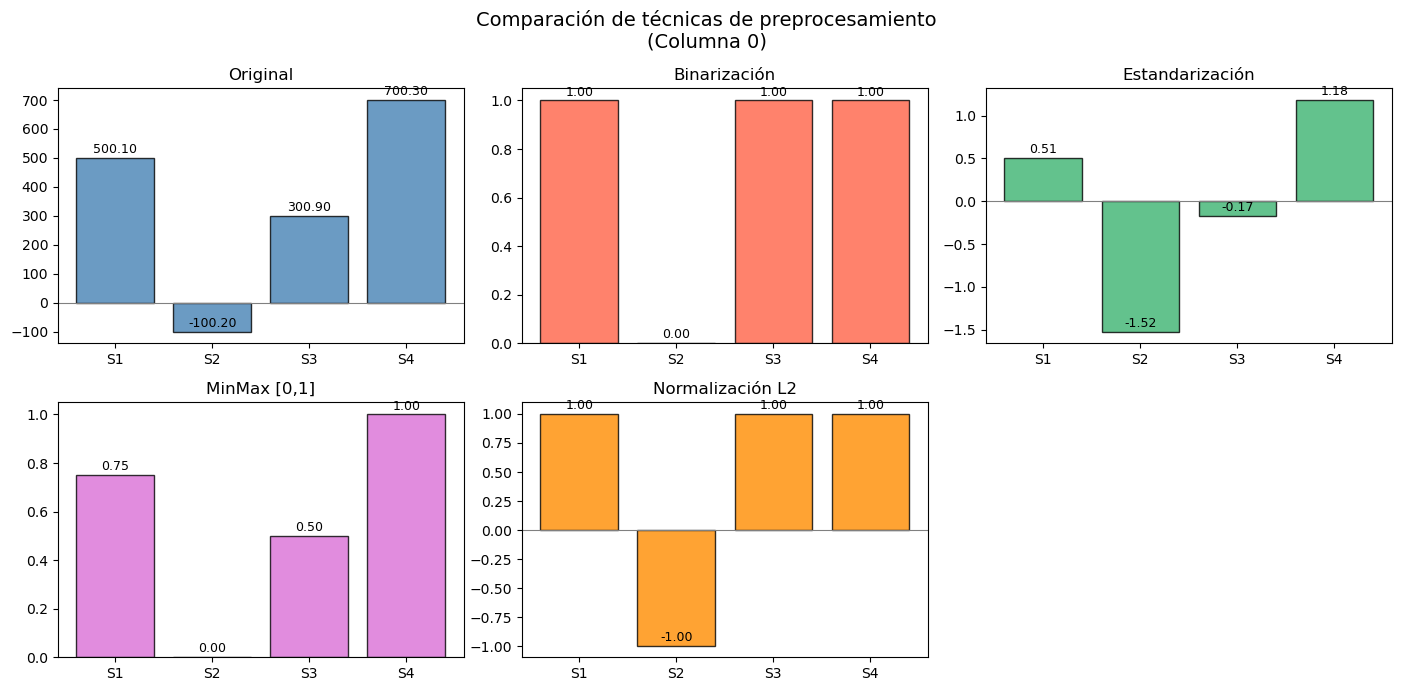

In [9]:
import matplotlib.pyplot as plt

# Calculamos todas las transformaciones para la primer columna
col = 0
original    = input_data[:, col]
binarized   = data_binarized[:, col]
standardized= data_scaled[:, col]
minmax      = data_scaled_minmax[:, col]
l2_norm     = data_normalized_l2[:, col]

labels = [f'S{i+1}' for i in range(len(original))]
x = range(len(original))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Comparación de técnicas de preprocesamiento\n(Columna 0)', fontsize=14)

def barplot(ax, values, title, color):
    ax.bar(labels, values, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title)
    ax.axhline(0, color='gray', linewidth=0.8)
    for i, v in enumerate(values):
        ax.text(i, v + (max(values)-min(values))*0.02, f'{v:.2f}',
                ha='center', fontsize=9)

barplot(axes[0,0], original,     'Original',           'steelblue')
barplot(axes[0,1], binarized,    'Binarización',        'tomato')
barplot(axes[0,2], standardized, 'Estandarización',     'mediumseagreen')
barplot(axes[1,0], minmax,       'MinMax [0,1]',        'orchid')
barplot(axes[1,1], l2_norm,      'Normalización L2',    'darkorange')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

## 🎓 Resumen y Conclusiones

En este notebook aprendimos las técnicas de preprocesamiento más importantes:

| Técnica | Clase scikit-learn | Cuándo usar |
|---------|-------------------|-------------|
| **Binarización** | `Binarizer(threshold)` | Convertir a 0/1 con un umbral |
| **Estandarización** | `StandardScaler` / `scale()` | Datos ≈ normales; SVM, PCA, Regresión |
| **MinMax Scaling** | `MinMaxScaler` | Rango fijo; KNN, Redes Neuronales |
| **Normalización** | `normalize(norm='l1'/'l2')` | Normalizar vectores por fila |
| **Label Encoding** | `LabelEncoder` | Variable objetivo categórica (ordinal) |

### 🚀 ¿Qué sigue?

- 🗺️ **K-Nearest Neighbors (KNN)**: donde el preprocesamiento es **fundamental** para que las distancias sean significativas
- 📐 **SVM**: otro algoritmo muy sensible a la escala de las features
- 🔠 **OneHotEncoder**: alternativa al LabelEncoder para variables sin orden implícito

> 📚 **Referencias:**
> - [scikit-learn — Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
> - [scikit-learn — LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)
> - [scikit-learn — MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)
> - [scikit-learn — StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

---

© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas

Este notebook se distribuye bajo licencia [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).